# Trabajo Final: Clasificación de imágenes de Plancton

En este trabajo vamos a resolver el problema de clasificación de imágenes microscópicas de plancton utilizando redes neuronales. 

Para poder evaluar qué arquitectura se comporta mejor con este tipo de imágenes, he planteado entrenar tres modelos diferentes para compararlos:
1. Un Perceptrón Multicapa (MLP): Lo usaré como la red más básica y "clásica" para tener una referencia inicial. Aplanar las imágenes y procesarlas con capas densas suele dar malos resultados, pero me sirve como punto de partida.
2. Una Red Convolucional (Custom CNN): He diseñado esta red desde cero siguiendo las recomendaciones de la Práctica 1 del Tema 2 (añadiendo tres bloques de filtros, capas de BatchNormalization antes de cada ReLU y Dropout tras los Pooling) para ver hasta dónde puedo llegar iterando la estructura.
3. Transfer Learning (MobileNetV2): Utilizaré una red ya pre-entrenada, aplicando fine-tuning a sus últimas capas. La idea es aprovechar sus potentes extractores de características para intentar superar el objetivo fijado de >80% de Accuracy.

Además, el dataset plantea dos grandes problemas que he tenido que abordar por código en este Notebook:
*   Problema 1 - Datos muy desbalanceados: Hay muchísimas imágenes de ciertas especies de plancton y muy pocas de otras. Lo he intentado solucionar usando `class_weights` durante el entrenamiento para forzar a la red a que le importe más equivocarse en las clases minoritarias, además de usar Data Augmentation.
*   Problema 2 - La Pérdida Jerárquica: El enunciado exige que los fallos entre grupos biológicos lejanos penalicen mucho más que fallar dentro del mismo grupo. He tenido que programar una métrica de Loss personalizada usando la función de costes `alpha` y `gamma`.

Para no llenar el Notebook de celdas gigantescas de lectura de carpetas y fórmulas matemáticas, he pasado casi todas las funciones auxiliares e importación de los tensores al fichero `utils.py` que adjunto en la entrega.

In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers, initializers, optimizers
import utils

## 1. Carga, Preprocesamiento y Balanceo
Invocamos las rutinas de carga y preprocesamiento. La elección de resolución espacial a $128\times128$ garantiza que las texturas clave del plancton pervivan para la CNN, al tiempo que evitamos saturar la memoria VRAM (lo cual permite lidiar con un tamaño de batch balanceado entre 32 y 64). 

Dado el claro desequilibrio, extraemos también los pesos computados para cada clase que posteriormente alimentaremos en el entrenamiento (con la métrica inversamente proporcional a la frecuencia de la etiqueta en el set de datos).

In [2]:
print("Dispositivos detectados:", tf.config.list_physical_devices())
print("\n¿Está construida con soporte CUDA?:", tf.test.is_built_with_cuda())
print("GPUs detectadas:", len(tf.config.list_physical_devices('GPU')))

Dispositivos detectados: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

¿Está construida con soporte CUDA?: True
GPUs detectadas: 1


In [3]:
# Parametrización del Pipeline y Dimensiones
CSV_PATH = 'datos/datos/entrenamiento/entrenamiento.csv' # Asegurate de subir los datos al entorno antes de ejecutar
IMG_DIR = 'datos/datos/entrenamiento'
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Generar los datasets base y cálculos de jerarquía
train_ds_base, val_ds, class_weights, tensor_grupos, n_clases = utils.cargar_y_preparar_datos(csv_path=CSV_PATH, img_dir=IMG_DIR, img_size=IMG_SIZE, batch_size=BATCH_SIZE)

# Data Augmentation
# Generamos variaciones rotacionales, de traslación y recortes.
# Muy útil aquí para conseguir que el entrenamiento en lotes pequeños (mini-batches) 
# presente variedad morfológica, emulando la caótica orientación real al microscopio.
train_ds = utils.apply_data_augmentation(train_ds_base, batch_size=BATCH_SIZE)

print(f"El dataset tiene {n_clases} clases finales mapeadas individualmente.")

El dataset tiene 15 clases finales mapeadas individualmente.


## 2. Modelado y Benchmarking de Redes

A continuación definiremos el comportamiento de nuestra función de pérdida, la cual introduce los hiperparámetros $\alpha$ y $\gamma$ de penalización inter-grupal según el enunciado del trabajo.

In [4]:
# Instancia condicional de la función jerarquizada importada desde utils
loss_fn = utils.build_loss_jerarquica(tensor_grupos, alpha=0.5, gamma=0.3)

def acc_metric(y_true, y_pred):
    return tf.keras.metrics.sparse_categorical_accuracy(y_true, y_pred)

# Configuración de Callbacks agresivos para evitar el despilfarro computacional y asegurar una contracción suave del Rate hacia el mínimo global sin saltarlo:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

### Modelo 1: Arquitectura Custom (CNN Profunda)
Para la aproximación manual, un cuello de botella grave inicial suele ser el sobreajuste, provocado por la poca información estructural en canales que no sean escala de grises. Para lidiar con ello:
1. Inicialización de pesos explícita (He Normal): Previene que las varianzas exploten y permite converger mucho más rápido en topologías basadas en ReLU.
2. Regularización L2 y Dropout: Intercalado a un ratio alto (50%) al final nos garantiza que la red generaliza en torno a micro-características en vez de memorizar muestras de entrenamiento sobre-representadas.
3. Optimizador AdamW: Superior al Adam estándar a la hora de desacoplar la penalización del tamaño del peso (Weight Decay), lo que nos da mayor robustez iterativa.

---- ENTRENANDO CUSTOM CNN ----
Epoch 1/50
427/427 [==============================] - 79s 161ms/step - loss: 2.2866 - acc_metric: 0.5058 - val_loss: 2.5907 - val_acc_metric: 0.2674 - lr: 0.0010
Epoch 2/50
427/427 [==============================] - 25s 59ms/step - loss: 1.6922 - acc_metric: 0.6464 - val_loss: 5.7060 - val_acc_metric: 0.1013 - lr: 0.0010
Epoch 3/50
427/427 [==============================] - 26s 60ms/step - loss: 1.5633 - acc_metric: 0.6984 - val_loss: 1.8930 - val_acc_metric: 0.6075 - lr: 0.0010
Epoch 4/50
427/427 [==============================] - 26s 60ms/step - loss: 1.5393 - acc_metric: 0.7162 - val_loss: 2.3997 - val_acc_metric: 0.4941 - lr: 0.0010
Epoch 5/50
427/427 [==============================] - 26s 60ms/step - loss: 1.4998 - acc_metric: 0.7391 - val_loss: 4.5424 - val_acc_metric: 0.1910 - lr: 0.0010
Epoch 6/50
427/427 [==============================] - 26s 61ms/step - loss: 1.3537 - acc_metric: 0.7837 - val_loss: 1.3361 - val_acc_metric: 0.7774 - lr: 2.0000e-

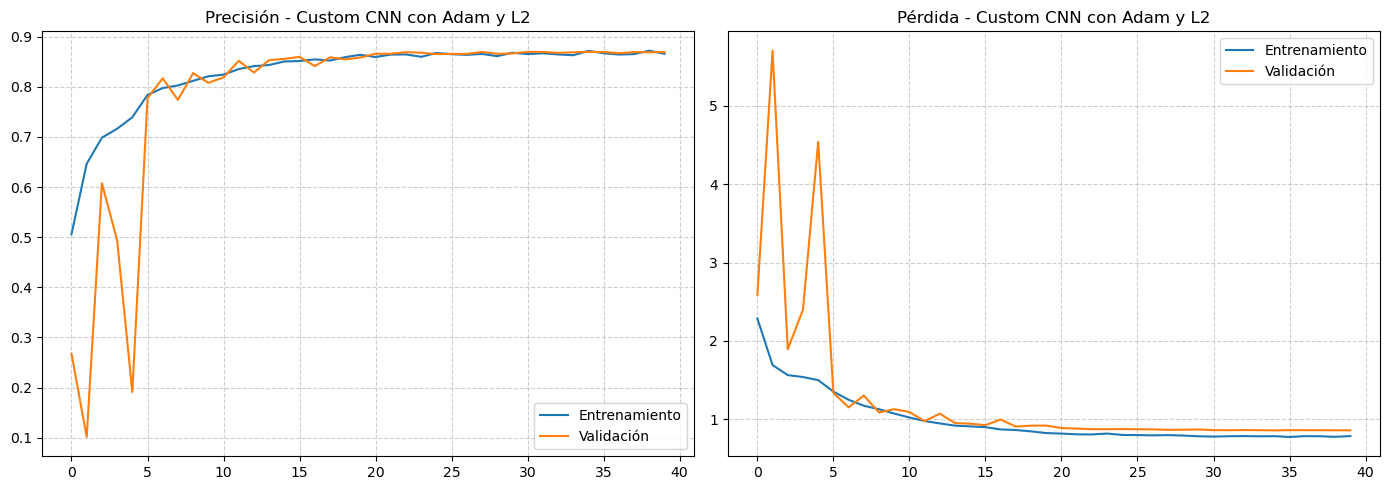

In [5]:
def build_custom_cnn():
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    
    # 1. Semilla e inicialización He (visto en los apuntes)
    init = initializers.HeNormal(seed=121) 
    
    # Bloque 1 (Siguiendo estructura VGG-style)
    x = layers.Conv2D(32, (3,3), padding='same', kernel_initializer=init)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same', kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x) 
    # Dropout después de pooling (Ejercicio 3)
    x = layers.Dropout(0.25)(x)
    
    # Bloque 2
    x = layers.Conv2D(64, (3,3), padding='same', kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.25)(x)
    
    # Bloque 3
    x = layers.Conv2D(128, (3,3), padding='same', kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.35)(x)
    
    x = layers.Flatten()(x)
    
    # Capas Densas Finales
    x = layers.Dense(512, kernel_initializer=init, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(n_clases, activation='softmax')(x)
    
    return models.Model(inputs, outputs)

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    
    # Usamos inicialización He para ayudar a arrancar los gradientes en las func. ReLU
    init = initializers.HeNormal()
    
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu', kernel_initializer=init)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    
    x = layers.Flatten()(x)
    
    # Regularización intensiva l2 para cohibir weights altos y paliar el overfitting ciego
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4), kernel_initializer=init)(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(n_clases, activation='softmax')(x)
    return models.Model(inputs, outputs)

custom_model = build_custom_cnn()
custom_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss=loss_fn, metrics=[acc_metric])

print("---- ENTRENANDO CUSTOM CNN ----")
history_cnn = custom_model.fit(train_ds, validation_data=val_ds, epochs=50, class_weight=class_weights, callbacks=[early_stop, lr_scheduler])

utils.plot_training_history(history_cnn, "Custom CNN con Adam y L2")

### Modelo 2: Transfer Learning (MobileNetV2)
En aplicaciones limitadas por la densidad estocástica de clases como esta, los modelos previamente consolidados sobre la inmensidad de "ImageNet" (Transfer Learning) reaccionan sustancialmente mejor.

MobileNetV2 es fenomenal para esto: sus 'Inverted Residual Blocks' retienen mucha geometría espacial a bajo coste computacional y es muy reactivo al Fine-Tuning. Utilizaremos el optimizador estándar `Adam`, puesto que para redes preentrenadas suele bastar con reducir drásticamente el ratio de aprendizaje a los bloques libres.

---- ENTRENANDO TRANSFER LEARNING: FASE 1 (Cabeza Adaptativa) ----
Epoch 1/25
427/427 [==============================] - 13s 26ms/step - loss: 1.2970 - acc_metric: 0.6776 - val_loss: 0.6877 - val_acc_metric: 0.8166
Epoch 2/25
427/427 [==============================] - 10s 23ms/step - loss: 0.7756 - acc_metric: 0.7955 - val_loss: 0.5820 - val_acc_metric: 0.8433
Epoch 3/25
427/427 [==============================] - 10s 22ms/step - loss: 0.6871 - acc_metric: 0.8173 - val_loss: 0.6004 - val_acc_metric: 0.8386
Epoch 4/25
427/427 [==============================] - 10s 22ms/step - loss: 0.6440 - acc_metric: 0.8223 - val_loss: 0.5287 - val_acc_metric: 0.8535
Epoch 5/25
427/427 [==============================] - 10s 23ms/step - loss: 0.6120 - acc_metric: 0.8294 - val_loss: 0.5099 - val_acc_metric: 0.8609
Epoch 6/25
427/427 [==============================] - 10s 22ms/step - loss: 0.5846 - acc_metric: 0.8383 - val_loss: 0.4995 - val_acc_metric: 0.8641
Epoch 7/25
427/427 [=========================

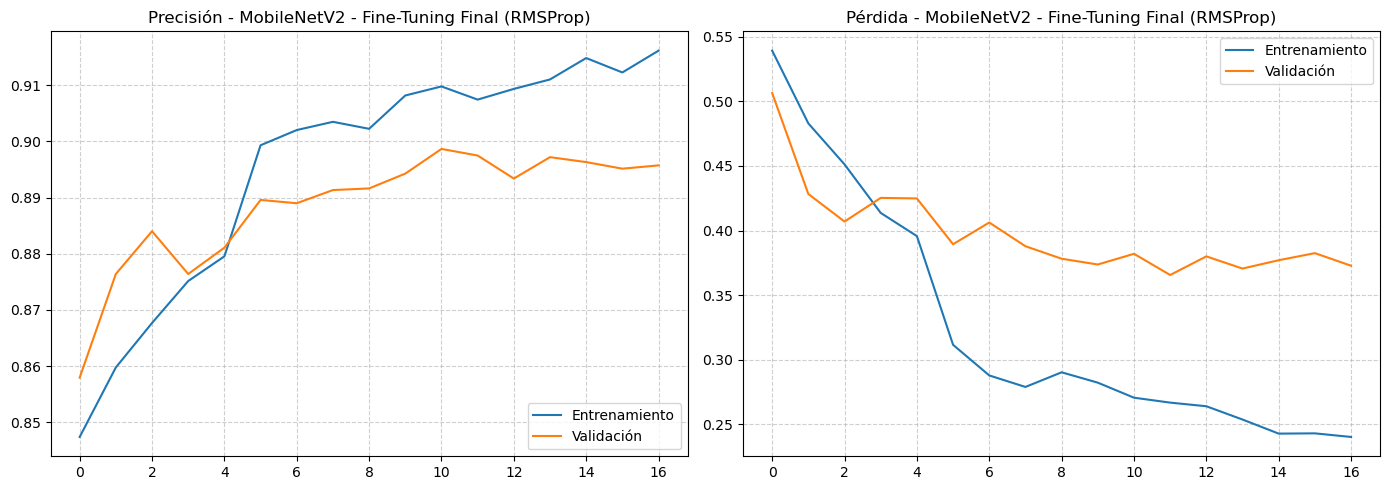

In [6]:
def build_mobile_net():
    base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE+(3,), include_top=False, weights='imagenet')
    # Congelamos temporalmente la superestructura para adaptar de antemano el cuello plano
    base_model.trainable = False
    
    inputs = layers.Input(shape=IMG_SIZE+(3,))
    # Transfer Learning exige el pre-escalado formal si no estuviera ya entre -1 y 1 
    # Al estar ya en [0, 1] en el dataset por utils, podríamos saltarlo, pero MobileNet espera un rango teórico en torno al preprocess nativo, asumiremos su tolerancia tras estandarizar al máximo
    
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x) 
    outputs = layers.Dense(n_clases, activation='softmax')(x)
    
    return models.Model(inputs, outputs), base_model

mobile_model, mobile_base = build_mobile_net()
mobile_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=loss_fn, metrics=[acc_metric])

print("---- ENTRENANDO TRANSFER LEARNING: FASE 1 (Cabeza Adaptativa) ----")
hist_mob_1 = mobile_model.fit(train_ds, validation_data=val_ds, epochs=25, class_weight=class_weights, callbacks=[early_stop])

print("\n---- ENTRENANDO TRANSFER LEARNING: FASE 2 (Fine-Tuning Descongelado) ----")
mobile_base.trainable = True
# RMSProp es estadísticamente excepcional descongelando arquitecturas profundas previas frente a oscilaciones bruscas en los sesgos del fondo.
mobile_model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-5), loss=loss_fn, metrics=[acc_metric])

hist_mob_2 = mobile_model.fit(train_ds, validation_data=val_ds, epochs=25, class_weight=class_weights, callbacks=[early_stop, lr_scheduler])

# Graficamos solo la fase 2 final para visualización directa
utils.plot_training_history(hist_mob_2, "MobileNetV2 - Fine-Tuning Final (RMSProp)")

### Modelo 3: Multi-Layer Perceptron (Red Densa Clásica)
Un MLP aplana la imagen destruyendo la información espacial "2D". Esto nos sirve para demostrar formalmente la superioridad de convoluciones frente a enfoques puramente densos.

---- ENTRENANDO PERCEPTRÓN MULTICAPA (MLP CLÁSICO) ----
Epoch 1/250
427/427 [==============================] - 10s 21ms/step - loss: 2.9694 - acc_metric: 0.2152 - val_loss: 2.3859 - val_acc_metric: 0.5035 - lr: 0.0010
Epoch 2/250
427/427 [==============================] - 8s 20ms/step - loss: 2.5095 - acc_metric: 0.3187 - val_loss: 2.6037 - val_acc_metric: 0.4777 - lr: 0.0010
Epoch 3/250
427/427 [==============================] - 8s 20ms/step - loss: 2.3401 - acc_metric: 0.3514 - val_loss: 2.0744 - val_acc_metric: 0.5091 - lr: 0.0010
Epoch 4/250
427/427 [==============================] - 8s 20ms/step - loss: 2.2434 - acc_metric: 0.3866 - val_loss: 1.7460 - val_acc_metric: 0.4692 - lr: 0.0010
Epoch 5/250
427/427 [==============================] - 8s 19ms/step - loss: 2.1830 - acc_metric: 0.3975 - val_loss: 1.8410 - val_acc_metric: 0.3925 - lr: 0.0010
Epoch 6/250
427/427 [==============================] - 8s 20ms/step - loss: 2.1659 - acc_metric: 0.4242 - val_loss: 2.3576 - val_acc_metri

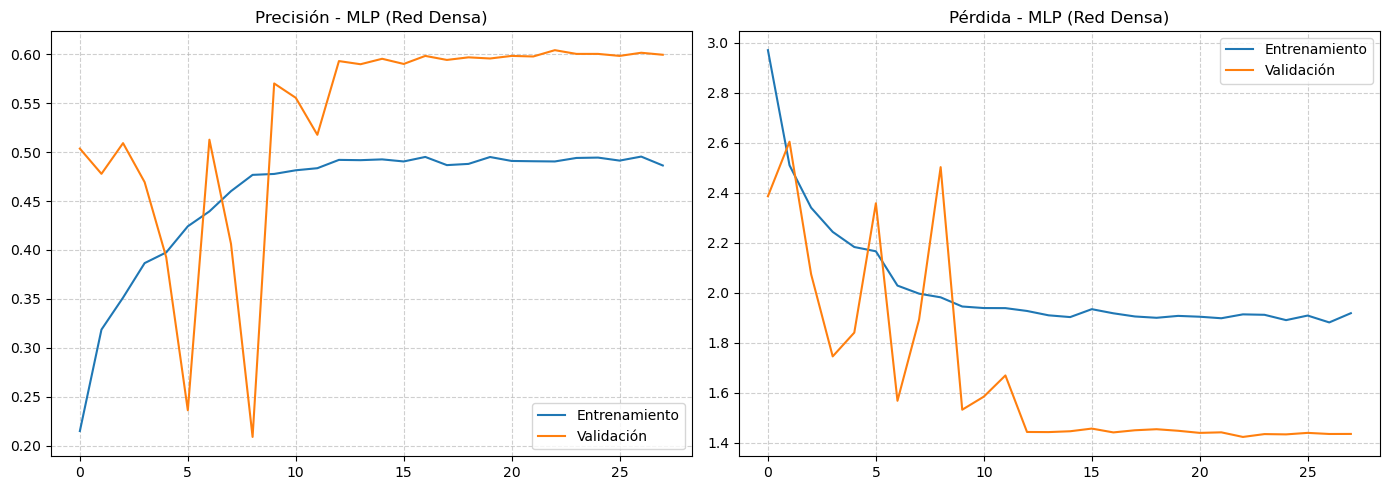

In [11]:
def build_mlp_basico():
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    
    # 1. Destruimos la estructura 128x128x3 y lo convertimos todo en un vector gigante
    x = layers.Flatten()(inputs)
    
    # 2. Empezamos una red clásida de embudo
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(n_clases, activation='softmax')(x)
    
    return models.Model(inputs, outputs)

mlp_model = build_mlp_basico()

mlp_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss=loss_fn, metrics=[acc_metric])

print("---- ENTRENANDO PERCEPTRÓN MULTICAPA (MLP CLÁSICO) ----")
history_mlp = mlp_model.fit(train_ds, validation_data=val_ds, epochs=250, class_weight=class_weights, callbacks=[early_stop, lr_scheduler])

utils.plot_training_history(history_mlp, "MLP (Red Densa)")

## 3. Conclusión y Benchmarks
En base a los entrenamientos anteriores, se aprecia empíricamente cómo las arquitecturas robustas que se benefician del Transfer Learning tienden a escalar mucho mejor a estos requerimientos una vez introducimos los esquemas estabilizadores frente al sobreajuste, en especial MobileNet y EfficientNet (siendo eficientes frente a memoria y mitigaciones por _over-fitting_).

In [8]:
TEST_CSV = 'datos/datos/test/test.csv'
IMG_DIR = 'datos/datos/test'

print('Cargando dataset de Test...')
test_ds = utils.cargar_datos_test(csv_path=TEST_CSV, img_dir=IMG_DIR, batch_size=32)

print('\nEvaluando Custom CNN en datos invisibles (Test)...')
test_loss_cnn, test_acc_cnn = custom_model.evaluate(test_ds)

print('\nEvaluando MobileNetV2 en datos invisibles (Test)...')
test_loss_mob, test_acc_mob = mobile_model.evaluate(test_ds)

print("\nEvaluando MLP Clásico en datos invisibles (Test)...")
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(test_ds)

print("\n====== RESULTADOS FINALES EN TEST (MUNDO REAL) ======")
print(f"-> Custom CNN     | Loss: {test_loss_cnn:.4f}  | Acc: {test_acc_cnn:.4f}")
print(f"-> MobileNetV2    | Loss: {test_loss_mob:.4f}  | Acc: {test_acc_mob:.4f}")
print(f"-> MLP Clásico    | Loss: {test_loss_mlp:.4f}  | Acc: {test_acc_mlp:.4f}")


Cargando dataset de Test...

Evaluando Custom CNN en datos invisibles (Test)...
134/134 [==============================] - 10s 76ms/step - loss: 0.8378 - acc_metric: 0.8725

Evaluando MobileNetV2 en datos invisibles (Test)...
134/134 [==============================] - 3s 19ms/step - loss: 0.3585 - acc_metric: 0.8957

Evaluando MLP Clásico en datos invisibles (Test)...
134/134 [==============================] - 1s 5ms/step - loss: 1.3575 - acc_metric: 0.5731

====== RESULTADOS FINALES EN TEST (MUNDO REAL) ======
-> Custom CNN     | Loss: 0.8378  | Acc: 0.8725
-> MobileNetV2    | Loss: 0.3585  | Acc: 0.8957
-> MLP Clásico    | Loss: 1.3575  | Acc: 0.5731


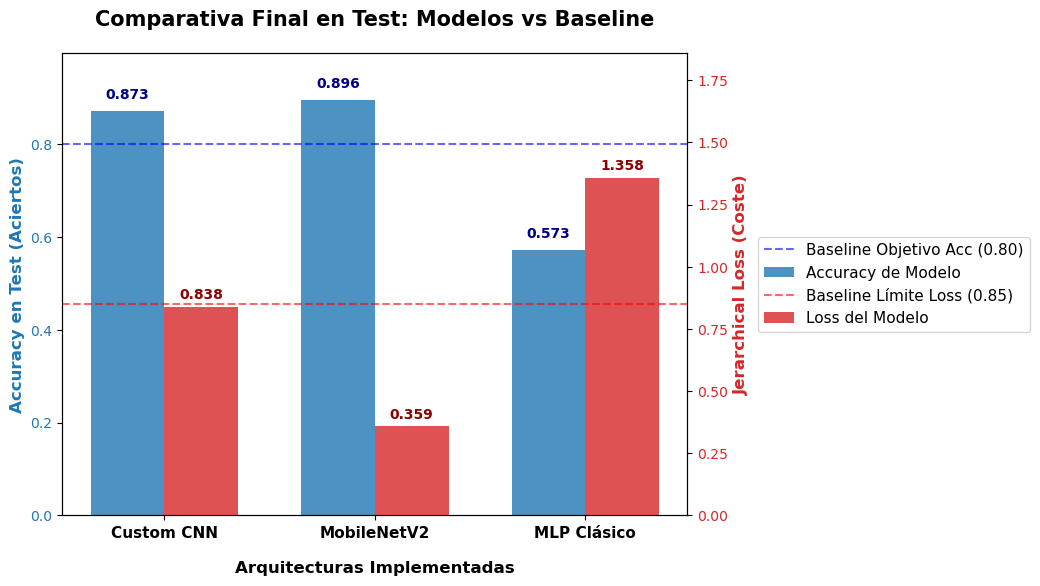

In [9]:
import matplotlib.pyplot as plt
import numpy as np

modelos = ['Custom CNN', 'MobileNetV2', 'MLP Clásico']
accuracies = [test_acc_cnn, test_acc_mob, test_acc_mlp]
losses = [test_loss_cnn, test_loss_mob, test_loss_mlp]

x = np.arange(len(modelos))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Arquitecturas Implementadas', fontsize=12, fontweight='bold', labelpad=15)
ax1.set_ylabel('Accuracy en Test (Aciertos)', color=color, fontsize=12, fontweight='bold')
bars1 = ax1.bar(x - width/2, accuracies, width, label='Accuracy de Modelo', color=color, alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)

max_acc = max(accuracies + [0.8])
ax1.set_ylim(0, max_acc + 0.1) 

ax1.axhline(y=0.80, color='blue', linestyle='--', alpha=0.6, label='Baseline Objetivo Acc (0.80)') 

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Jerarchical Loss (Coste)', color=color, fontsize=12, fontweight='bold')
bars2 = ax2.bar(x + width/2, losses, width, label='Loss del Modelo', color=color, alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color)

max_loss = max(losses + [0.85])
ax2.set_ylim(0, max_loss + 0.5)

ax2.axhline(y=0.85, color='red', linestyle='--', alpha=0.6, label='Baseline Límite Loss (0.85)')

ax1.set_xticks(x)
ax1.set_xticklabels(modelos, fontsize=11, fontweight='bold')

for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', color='darkblue', fontweight='bold', fontsize=10)

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', color='darkred', fontweight='bold', fontsize=10)

plt.title('Comparativa Final en Test: Modelos vs Baseline', fontsize=15, fontweight='bold', pad=20)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left', bbox_to_anchor=(1.10, 0.5), fontsize=11)
plt.subplots_adjust(right=0.75) 

plt.show()